# 06 — Cross-Dataset Analysis

## 1.1 Purpose

This notebook compares the MovieLens-1M and Amazon Video Games results after each dataset has been analysed independently.

The goal is to identify which recommender-system behaviours are consistent across datasets and which appear to depend on dataset characteristics.

The analysis compares:

- baseline model rankings;
- ranking consistency between datasets;
- relative NDCG@10 changes under sparsity;
- model robustness patterns;
- severe-sparsity behaviour;
- sparsity-scenario effects;
- unseen evaluation targets;
- interaction-retention differences;
- model-family patterns.

Raw NDCG values are not treated as directly comparable across datasets because MovieLens and Amazon differ substantially in density, catalogue size, history length, and actual retained interaction percentages.

Cross-dataset comparisons therefore focus primarily on rankings, relative changes, and qualitative patterns.

## 1.2 Setup

Load required libraries and create directories for cross-dataset tables and figures.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


# ---------------------------------------------------------------------
# Locate repository root
# ---------------------------------------------------------------------

def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()

    for candidate in [start, *start.parents]:
        if (
            (candidate / "results").exists()
            and (candidate / "scripts").exists()
            and (candidate / "configs").exists()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not locate repository root."
    )


ROOT = find_repo_root()

BASELINE_TABLE_DIR = (
    ROOT / "results" / "tables" / "baseline"
)

SPARSITY_TABLE_DIR = (
    ROOT / "results" / "tables" / "sparsity"
)

FIGURE_DIR = (
    ROOT / "results" / "figures" / "cross_dataset"
)

TABLE_DIR = (
    ROOT / "results" / "tables" / "cross_dataset"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


print(f"Repository root : {ROOT}")
print(f"Figure directory: {FIGURE_DIR}")
print(f"Table directory : {TABLE_DIR}")


plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.alpha": 0.25,
})

Repository root : C:\Research Project\recommender-sparsity-honours
Figure directory: C:\Research Project\recommender-sparsity-honours\results\figures\cross_dataset
Table directory : C:\Research Project\recommender-sparsity-honours\results\tables\cross_dataset


## 1.3 Prerequisite checks

Confirm that final-result verification passed and that the baseline and sparsity notebooks produced their required analysis tables.

In [2]:
verification_path = (
    ROOT
    / "results"
    / "verification"
    / "verification_summary.json"
)

required_files = {
    "baseline_summary": (
        BASELINE_TABLE_DIR
        / "baseline_summary_full.csv"
    ),
    "sparsity_summary": (
        SPARSITY_TABLE_DIR
        / "sparsity_summary_full.csv"
    ),
    "condition_stats": (
        SPARSITY_TABLE_DIR
        / "condition_data_statistics.csv"
    ),
}


if not verification_path.exists():
    raise FileNotFoundError(
        "Run 03_results_verification.ipynb first."
    )


with open(
    verification_path,
    "r",
    encoding="utf-8",
) as f:
    verification = json.load(f)


print("Verification summary")
print("--------------------")
print(f"PASS : {verification['pass']}")
print(f"WARN : {verification['warn']}")
print(f"FAIL : {verification['fail']}")

if verification["fail"] > 0:
    raise RuntimeError(
        "Verification contains FAIL checks."
    )


print("\nRequired analysis tables:")

for name, path in required_files.items():
    exists = path.exists()

    print(
        f"{name:<20} : "
        f"{'FOUND' if exists else 'MISSING'}"
    )

    if not exists:
        raise FileNotFoundError(path)


print(
    "\nAll prerequisite files are available."
)

Verification summary
--------------------
PASS : 362
WARN : 2
FAIL : 0

Required analysis tables:
baseline_summary     : FOUND
sparsity_summary     : FOUND
condition_stats      : FOUND

All prerequisite files are available.


# 2. Cross-Dataset Data Preparation

## 2.1 Load analysis summaries

Load the baseline, sparsity, and condition-level statistics generated by the previous notebooks.

In [3]:
baseline_summary = pd.read_csv(
    required_files["baseline_summary"]
)

sparsity_summary = pd.read_csv(
    required_files["sparsity_summary"]
)

condition_stats = pd.read_csv(
    required_files["condition_stats"]
)


print(
    f"Baseline summary rows : "
    f"{len(baseline_summary)}"
)

print(
    f"Sparsity summary rows : "
    f"{len(sparsity_summary)}"
)

print(
    f"Condition-stat rows   : "
    f"{len(condition_stats)}"
)


assert len(baseline_summary) == 20
assert len(sparsity_summary) == 200
assert len(condition_stats) == 20

assert set(
    baseline_summary["dataset"]
) == {
    "movielens",
    "amazon",
}

print(
    "\nCross-dataset analysis data loaded correctly."
)

Baseline summary rows : 20
Sparsity summary rows : 200
Condition-stat rows   : 20

Cross-dataset analysis data loaded correctly.


## 2.2 Analysis metadata

Define consistent model, scenario, and dataset labels.

In [4]:
MODEL_FAMILY = {
    "Pop": "Non-personalized",
    "ItemKNN": "Classical",
    "BPR": "Classical",
    "EASE": "Linear",
    "NeuMF": "Neural",
    "MultiVAE": "Neural",
    "GRU4Rec": "Sequential",
    "SASRec": "Sequential",
    "BERT4Rec": "Sequential",
    "LightGCN": "Graph",
}

MODEL_ORDER = [
    "Pop",
    "ItemKNN",
    "BPR",
    "EASE",
    "NeuMF",
    "MultiVAE",
    "GRU4Rec",
    "SASRec",
    "BERT4Rec",
    "LightGCN",
]

SCENARIO_LABELS = {
    "baseline": "Baseline",
    "global": "Random per-user",
    "recent": "Recent-history",
    "early": "Early-profile",
}

DATASET_LABELS = {
    "movielens": "MovieLens-1M",
    "amazon": "Amazon Video Games",
}

SPARSE_SCENARIOS = [
    "global",
    "recent",
    "early",
]


def condition_label(
    scenario,
    retention,
):
    if scenario == "baseline":
        return "Baseline"

    return (
        f"{SCENARIO_LABELS[scenario]} "
        f"{int(retention)}%"
    )


def save_figure(
    fig,
    filename,
):
    fig.savefig(
        FIGURE_DIR / f"{filename}.png",
        bbox_inches="tight",
    )

    fig.savefig(
        FIGURE_DIR / f"{filename}.pdf",
        bbox_inches="tight",
    )

# 3. Dataset Context

## 3.1 Experimental-data characteristics

Compare the amount of available training information and item exposure in each dataset.

These differences provide context for interpreting later cross-dataset performance patterns.

In [5]:
baseline_conditions = (
    condition_stats[
        condition_stats["scenario"]
        == "baseline"
    ]
    .copy()
)


dataset_context = baseline_conditions[
    [
        "dataset",
        "users",
        "training_interactions",
        "training_unique_items",
        "mean_training_interactions_per_user",
        "test_unseen_percent",
    ]
].copy()

dataset_context[
    "dataset"
] = dataset_context[
    "dataset"
].map(DATASET_LABELS)

dataset_context.columns = [
    "Dataset",
    "Users",
    "Training Interactions",
    "Training Items",
    "Mean Training Interactions/User",
    "Baseline Test Targets Unseen (%)",
]


display(
    dataset_context.style.format({
        "Mean Training Interactions/User": "{:.2f}",
        "Baseline Test Targets Unseen (%)": "{:.3f}%",
    })
)

,Dataset,Users,Training Interactions,Training Items,Mean Training Interactions/User,Baseline Test Targets Unseen (%)
0,Amazon Video Games,63413,406724,18966,6.41,0.358%
10,MovieLens-1M,6034,562308,3125,93.19,0.000%


## 3.2 Nominal and actual retention

Compare the actual aggregate amount of training data retained at each nominal per-user retention level.

This distinction is especially important for Amazon because short histories cause the ceiling rule to retain substantially more than the nominal aggregate percentage.

In [6]:
retention_comparison = (
    condition_stats[
        condition_stats[
            "scenario"
        ].isin([
            "baseline",
            "global",
        ])
    ]
    [
        [
            "dataset",
            "retention_level",
            "actual_retention_percent",
            "mean_training_interactions_per_user",
        ]
    ]
    .drop_duplicates()
)


retention_comparison[
    "Dataset"
] = retention_comparison[
    "dataset"
].map(DATASET_LABELS)


retention_comparison = (
    retention_comparison[
        [
            "Dataset",
            "retention_level",
            "actual_retention_percent",
            "mean_training_interactions_per_user",
        ]
    ]
    .rename(columns={
        "retention_level":
            "Nominal Retention (%)",
        "actual_retention_percent":
            "Actual Retention (%)",
        "mean_training_interactions_per_user":
            "Mean Training Interactions/User",
    })
    .sort_values(
        [
            "Nominal Retention (%)",
            "Dataset",
        ],
        ascending=[
            False,
            True,
        ],
    )
)


display(
    retention_comparison.style.format({
        "Actual Retention (%)": "{:.3f}%",
        "Mean Training Interactions/User": "{:.2f}",
    })
)

,Dataset,Nominal Retention (%),Actual Retention (%),Mean Training Interactions/User
0,Amazon Video Games,100,100.000%,6.41
10,MovieLens-1M,100,100.000%,93.19
6,Amazon Video Games,50,54.712%,3.51
16,MovieLens-1M,50,50.270%,46.85
5,Amazon Video Games,25,29.767%,1.91
15,MovieLens-1M,25,25.404%,23.67
4,Amazon Video Games,10,18.380%,1.18
14,MovieLens-1M,10,10.479%,9.76


# 4. Baseline Cross-Dataset Comparison

## 4.1 Baseline NDCG@10 rankings

Compare model rankings rather than raw metric magnitude across datasets.

In [7]:
baseline_rank_table = (
    baseline_summary[
        [
            "dataset",
            "model",
            "model_family",
            "test_ndcg@10_mean",
            "test_ndcg@10_rank",
            "test_recall@10_rank",
            "test_mrr@10_rank",
        ]
    ]
    .pivot(
        index=[
            "model",
            "model_family",
        ],
        columns="dataset",
    )
)


baseline_rank_table.columns = [
    f"{metric}_{dataset}"
    for metric, dataset
    in baseline_rank_table.columns
]


baseline_rank_table = (
    baseline_rank_table
    .reset_index()
)


baseline_rank_table[
    "ndcg_rank_change"
] = (
    baseline_rank_table[
        "test_ndcg@10_rank_amazon"
    ]
    - baseline_rank_table[
        "test_ndcg@10_rank_movielens"
    ]
)


baseline_rank_table = (
    baseline_rank_table
    .sort_values(
        "test_ndcg@10_rank_movielens"
    )
    .reset_index(drop=True)
)


display(
    baseline_rank_table[
        [
            "model",
            "model_family",
            "test_ndcg@10_rank_movielens",
            "test_ndcg@10_rank_amazon",
            "ndcg_rank_change",
        ]
    ].rename(columns={
        "model": "Model",
        "model_family": "Family",
        "test_ndcg@10_rank_movielens":
            "MovieLens Rank",
        "test_ndcg@10_rank_amazon":
            "Amazon Rank",
        "ndcg_rank_change":
            "Amazon − MovieLens Rank",
    })
)

,Model,Family,MovieLens Rank,Amazon Rank,Amazon − MovieLens Rank
0,SASRec,Sequential,1,1,0
1,GRU4Rec,Sequential,2,2,0
2,BERT4Rec,Sequential,3,4,1
3,EASE,Linear,4,3,-1
4,MultiVAE,Neural,5,7,2
5,LightGCN,Graph,6,5,-1
6,BPR,Classical,7,6,-1
7,ItemKNN,Classical,8,9,1
8,NeuMF,Neural,9,8,-1
9,Pop,Non-personalized,10,10,0


## 4.2 Baseline rank agreement

Calculate Spearman rank correlation between the MovieLens and Amazon baseline model rankings.

In [8]:
baseline_rank_spearman = (
    baseline_rank_table[
        "test_ndcg@10_rank_movielens"
    ]
    .corr(
        baseline_rank_table[
            "test_ndcg@10_rank_amazon"
        ],
        method="spearman",
    )
)


print(
    "MovieLens vs Amazon "
    "baseline NDCG@10 rank correlation:"
)

print(
    f"Spearman ρ = "
    f"{baseline_rank_spearman:.3f}"
)

MovieLens vs Amazon baseline NDCG@10 rank correlation:
Spearman ρ = 0.939


## 4.3 Baseline rank movement

Visualise how each model's NDCG@10 rank changes between MovieLens and Amazon.

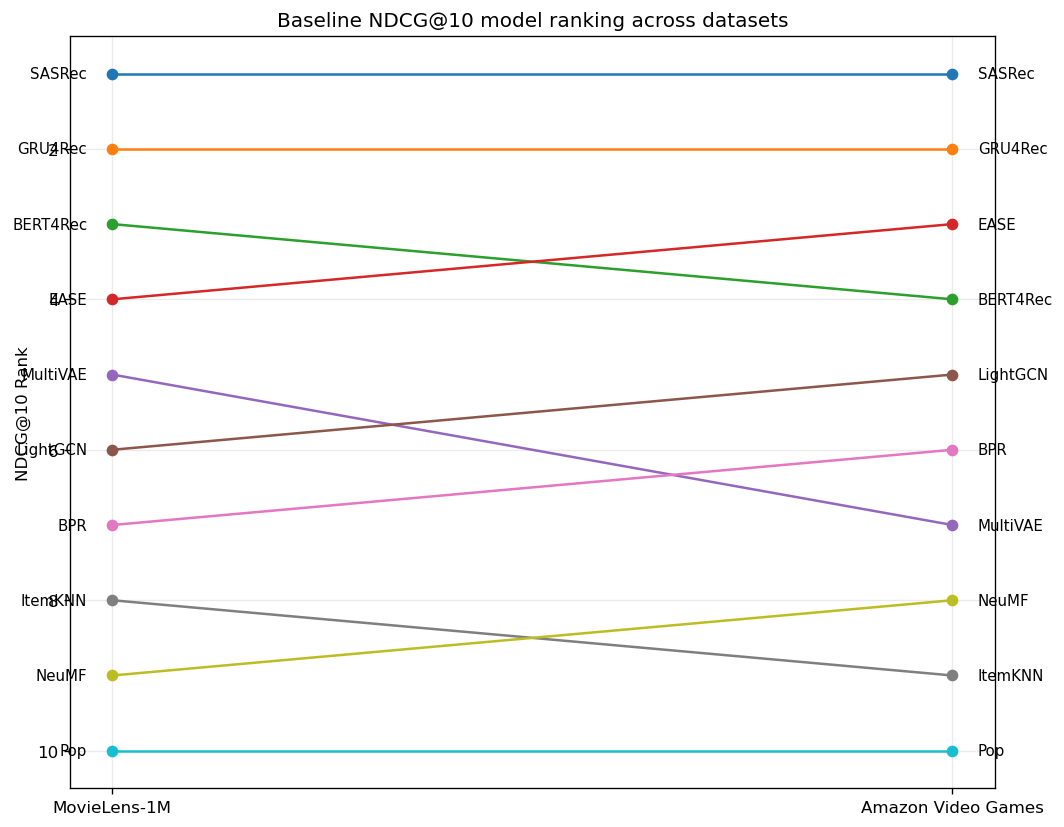

In [9]:
fig, ax = plt.subplots(
    figsize=(9, 7)
)

for _, row in baseline_rank_table.iterrows():

    x = [
        0,
        1,
    ]

    y = [
        row[
            "test_ndcg@10_rank_movielens"
        ],
        row[
            "test_ndcg@10_rank_amazon"
        ],
    ]

    ax.plot(
        x,
        y,
        marker="o",
    )

    ax.text(
        -0.03,
        y[0],
        row["model"],
        ha="right",
        va="center",
        fontsize=9,
    )

    ax.text(
        1.03,
        y[1],
        row["model"],
        ha="left",
        va="center",
        fontsize=9,
    )


ax.set_xticks(
    [0, 1],
    [
        "MovieLens-1M",
        "Amazon Video Games",
    ],
)

ax.set_ylabel(
    "NDCG@10 Rank"
)

ax.set_title(
    "Baseline NDCG@10 model ranking across datasets"
)

ax.set_ylim(
    10.5,
    0.5,
)

fig.tight_layout()

save_figure(
    fig,
    "baseline_rank_comparison",
)

plt.show()

# 5. Cross-Dataset Robustness

## 5.1 Median model performance change

Summarise the median relative NDCG@10 change across the same ten models within each dataset and sparsity condition.

The median is used only as a descriptive summary of the common direction and magnitude of model behaviour; individual model results remain the main basis for interpretation.

In [10]:
dataset_robustness = (
    sparsity_summary[
        sparsity_summary[
            "scenario"
        ] != "baseline"
    ]
    .groupby(
        [
            "dataset",
            "scenario",
            "retention_level",
        ],
        as_index=False,
    )
    .agg(
        median_relative_change=(
            "relative_change_ndcg10_pct_mean",
            "median",
        ),
        mean_relative_change=(
            "relative_change_ndcg10_pct_mean",
            "mean",
        ),
        best_relative_change=(
            "relative_change_ndcg10_pct_mean",
            "max",
        ),
        worst_relative_change=(
            "relative_change_ndcg10_pct_mean",
            "min",
        ),
    )
)


dataset_robustness[
    "Dataset"
] = dataset_robustness[
    "dataset"
].map(DATASET_LABELS)

dataset_robustness[
    "Scenario"
] = dataset_robustness[
    "scenario"
].map(SCENARIO_LABELS)


display(
    dataset_robustness[
        [
            "Dataset",
            "Scenario",
            "retention_level",
            "median_relative_change",
            "mean_relative_change",
        ]
    ]
    .rename(columns={
        "retention_level":
            "Nominal Retention (%)",
        "median_relative_change":
            "Median NDCG@10 Change (%)",
        "mean_relative_change":
            "Mean NDCG@10 Change (%)",
    })
    .style.format({
        "Median NDCG@10 Change (%)": "{:+.2f}%",
        "Mean NDCG@10 Change (%)": "{:+.2f}%",
    })
)

,Dataset,Scenario,Nominal Retention (%),Median NDCG@10 Change (%),Mean NDCG@10 Change (%)
0,Amazon Video Games,Early-profile,10,-68.52%,-67.20%
1,Amazon Video Games,Early-profile,25,-65.64%,-62.63%
2,Amazon Video Games,Early-profile,50,-41.02%,-41.59%
3,Amazon Video Games,Random per-user,10,-63.61%,-62.71%
4,Amazon Video Games,Random per-user,25,-61.52%,-57.25%
5,Amazon Video Games,Random per-user,50,-33.50%,-34.74%
6,Amazon Video Games,Recent-history,10,-63.54%,-58.08%
7,Amazon Video Games,Recent-history,25,-45.22%,-45.43%
8,Amazon Video Games,Recent-history,50,-20.27%,-22.10%
9,MovieLens-1M,Early-profile,10,-74.68%,-72.53%


## 5.2 Scenario-level robustness

Compare the median relative NDCG@10 change across datasets for each sparsity mechanism.

The x-axis shows nominal per-user retention. Actual aggregate retention differs between datasets and is reported separately in Section 3.2.

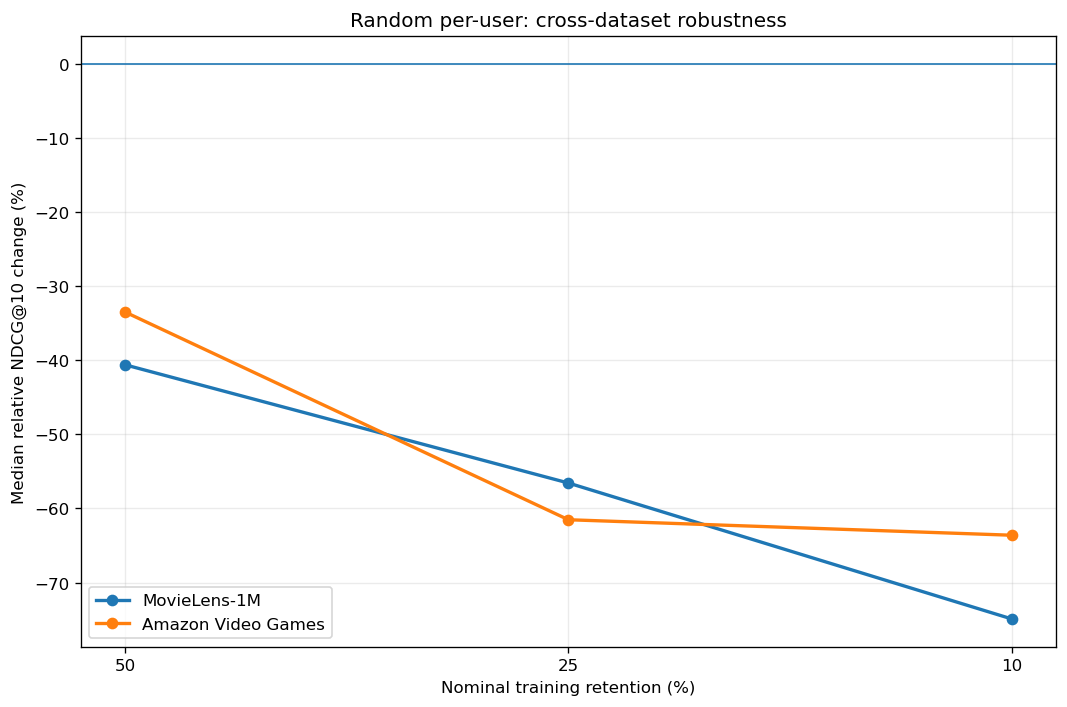

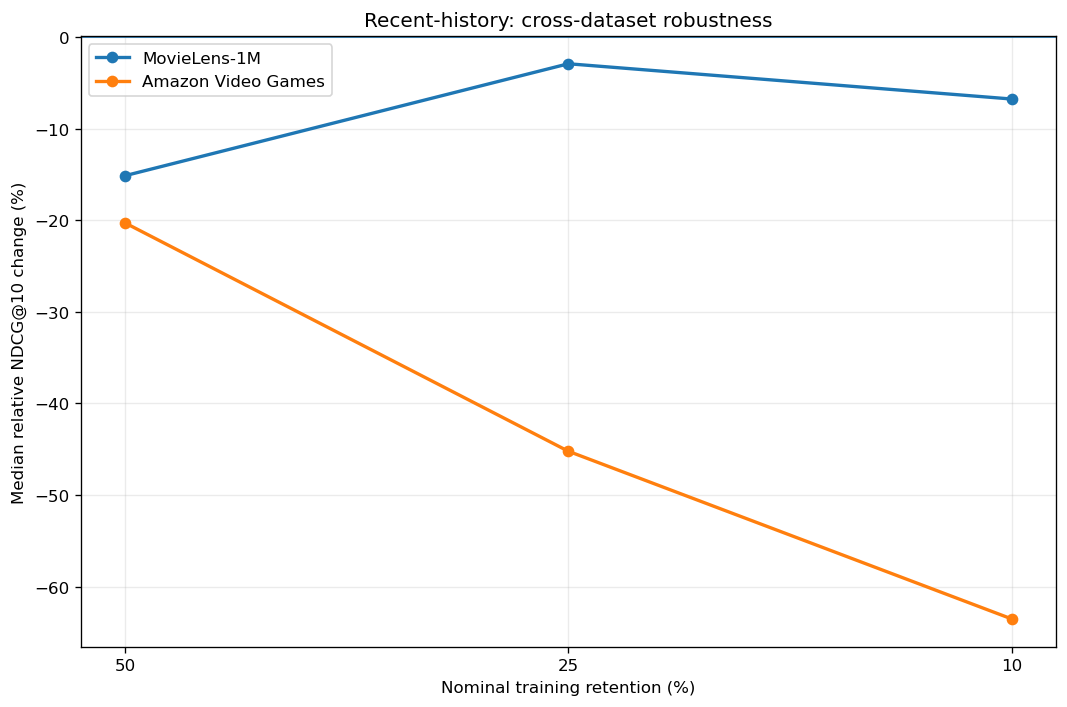

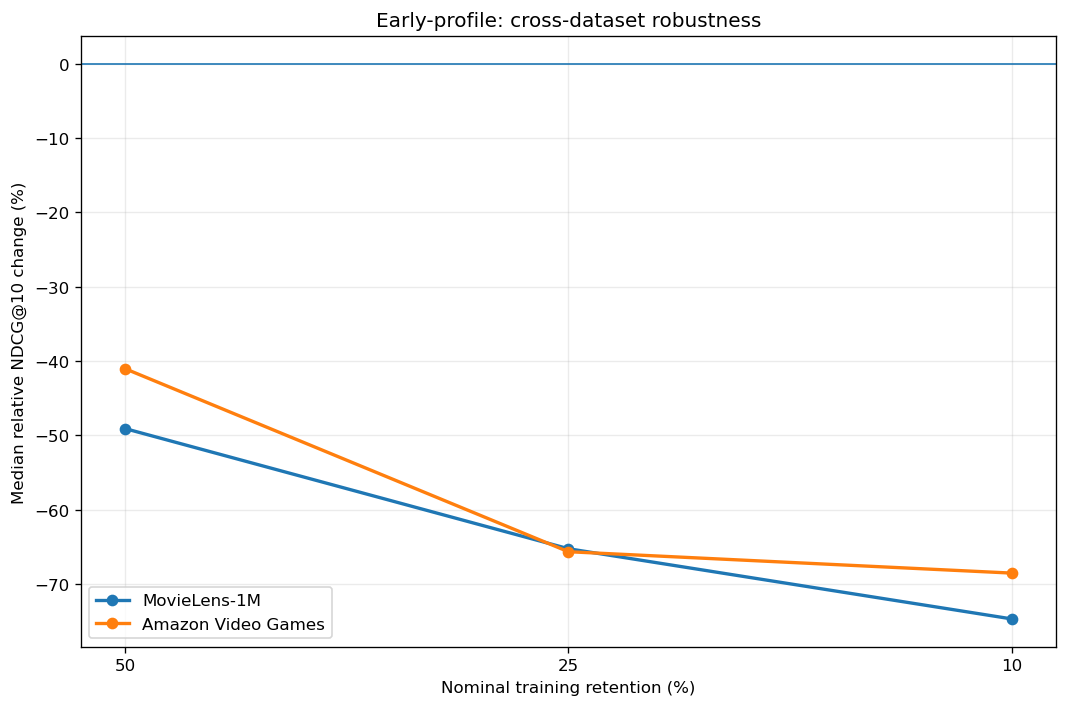

In [11]:
def plot_dataset_robustness(
    robustness,
    scenario,
    filename,
):

    fig, ax = plt.subplots(
        figsize=(9, 6)
    )

    x_labels = [
        "50",
        "25",
        "10",
    ]

    x = np.arange(
        len(x_labels)
    )

    for dataset in [
        "movielens",
        "amazon",
    ]:

        subset = robustness[
            (robustness["dataset"] == dataset)
            & (
                robustness["scenario"]
                == scenario
            )
        ]

        values = []

        for retention in [
            50,
            25,
            10,
        ]:

            value = subset[
                subset[
                    "retention_level"
                ] == retention
            ][
                "median_relative_change"
            ].iloc[0]

            values.append(value)

        ax.plot(
            x,
            values,
            marker="o",
            linewidth=2,
            label=DATASET_LABELS[
                dataset
            ],
        )

    ax.axhline(
        0,
        linewidth=1,
    )

    ax.set_xticks(
        x,
        x_labels,
    )

    ax.set_xlabel(
        "Nominal training retention (%)"
    )

    ax.set_ylabel(
        "Median relative NDCG@10 change (%)"
    )

    ax.set_title(
        f"{SCENARIO_LABELS[scenario]}: "
        "cross-dataset robustness"
    )

    ax.legend()

    fig.tight_layout()

    save_figure(
        fig,
        filename,
    )

    plt.show()


for scenario in SPARSE_SCENARIOS:

    plot_dataset_robustness(
        dataset_robustness,
        scenario,
        f"{scenario}_median_relative_change",
    )

# 6. Model-Level Cross-Dataset Behaviour

## 6.1 Severe sparsity

Compare each model's relative NDCG@10 change on MovieLens and Amazon at nominal 10% retention.

Points near the diagonal show models with similar relative degradation across datasets. Large deviations indicate dataset-dependent behaviour.

In [12]:
def severe_cross_dataset_table(
    summary,
    scenario,
):

    severe = summary[
        (summary["scenario"] == scenario)
        & (
            summary["retention_level"]
            == 10
        )
    ][
        [
            "dataset",
            "model",
            "model_family",
            "test_ndcg@10_mean",
            "test_ndcg@10_rank",
            "relative_change_ndcg10_pct_mean",
        ]
    ]

    pivot = severe.pivot(
        index=[
            "model",
            "model_family",
        ],
        columns="dataset",
        values=[
            "test_ndcg@10_rank",
            "relative_change_ndcg10_pct_mean",
        ],
    )

    pivot.columns = [
        f"{metric}_{dataset}"
        for metric, dataset
        in pivot.columns
    ]

    return (
        pivot
        .reset_index()
        .sort_values(
            "test_ndcg@10_rank_movielens"
        )
        .reset_index(drop=True)
    )


severe_tables = {}

for scenario in SPARSE_SCENARIOS:

    severe_tables[
        scenario
    ] = severe_cross_dataset_table(
        sparsity_summary,
        scenario,
    )

    print(
        f"\n{SCENARIO_LABELS[scenario]}"
    )

    display(
        severe_tables[scenario]
        .style.format({
            "relative_change_ndcg10_pct_mean_movielens":
                "{:+.2f}%",
            "relative_change_ndcg10_pct_mean_amazon":
                "{:+.2f}%",
        })
    )


Random per-user


,model,model_family,test_ndcg@10_rank_amazon,test_ndcg@10_rank_movielens,relative_change_ndcg10_pct_mean_amazon,relative_change_ndcg10_pct_mean_movielens
0,SASRec,Sequential,2.000000,1.000000,-56.79%,-77.71%
1,GRU4Rec,Sequential,1.000000,2.000000,-54.13%,-79.66%
2,BERT4Rec,Sequential,5.000000,3.000000,-61.96%,-83.73%
3,Pop,Non-personalized,3.000000,4.000000,-3.17%,-30.56%
4,NeuMF,Neural,4.000000,5.000000,-36.99%,-62.31%
5,MultiVAE,Neural,6.000000,6.000000,-65.27%,-71.34%
6,EASE,Linear,9.000000,7.000000,-89.81%,-75.17%
7,LightGCN,Graph,7.000000,8.000000,-80.86%,-70.60%
8,BPR,Classical,8.000000,9.000000,-87.46%,-74.64%
9,ItemKNN,Classical,10.000000,10.000000,-90.68%,-97.43%



Recent-history


,model,model_family,test_ndcg@10_rank_amazon,test_ndcg@10_rank_movielens,relative_change_ndcg10_pct_mean_amazon,relative_change_ndcg10_pct_mean_movielens
0,SASRec,Sequential,1.000000,1.000000,-40.03%,-54.03%
1,GRU4Rec,Sequential,2.000000,2.000000,-52.71%,-54.24%
2,EASE,Linear,7.000000,3.000000,-78.54%,+2.04%
3,LightGCN,Graph,8.000000,4.000000,-77.78%,+9.13%
4,MultiVAE,Neural,6.000000,5.000000,-64.03%,+5.94%
5,BERT4Rec,Sequential,5.000000,6.000000,-63.05%,-63.56%
6,BPR,Classical,9.000000,7.000000,-86.48%,-3.21%
7,NeuMF,Neural,4.000000,8.000000,-35.17%,+8.56%
8,ItemKNN,Classical,10.000000,9.000000,-83.02%,-21.00%
9,Pop,Non-personalized,3.000000,10.000000,+0.05%,-10.24%



Early-profile


,model,model_family,test_ndcg@10_rank_amazon,test_ndcg@10_rank_movielens,relative_change_ndcg10_pct_mean_amazon,relative_change_ndcg10_pct_mean_movielens
0,SASRec,Sequential,1.000000,1.000000,-63.91%,-82.01%
1,GRU4Rec,Sequential,2.000000,2.000000,-63.16%,-87.78%
2,BERT4Rec,Sequential,5.000000,3.000000,-69.12%,-87.88%
3,MultiVAE,Neural,6.000000,4.000000,-67.91%,-68.09%
4,Pop,Non-personalized,3.000000,5.000000,-9.14%,-37.29%
5,EASE,Linear,9.000000,6.000000,-90.44%,-74.42%
6,NeuMF,Neural,4.000000,7.000000,-46.08%,-65.39%
7,BPR,Classical,8.000000,8.000000,-88.28%,-71.02%
8,LightGCN,Graph,7.000000,9.000000,-82.10%,-74.94%
9,ItemKNN,Classical,10.000000,10.000000,-91.83%,-76.44%


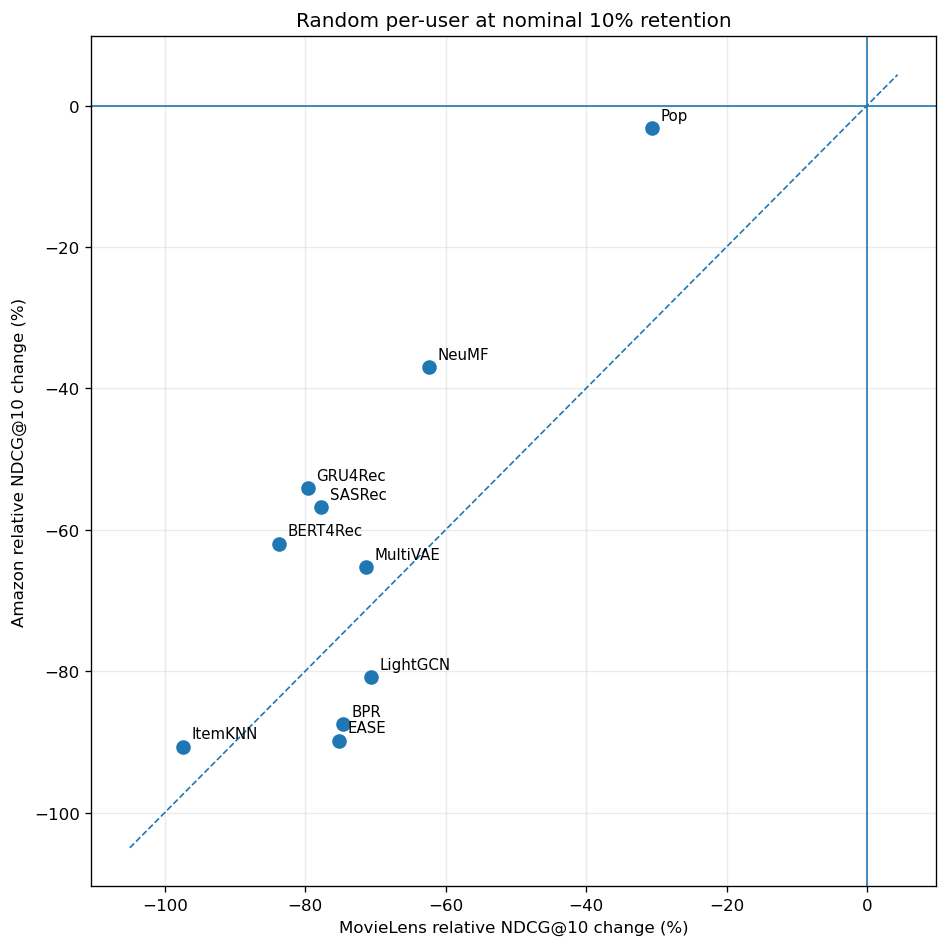

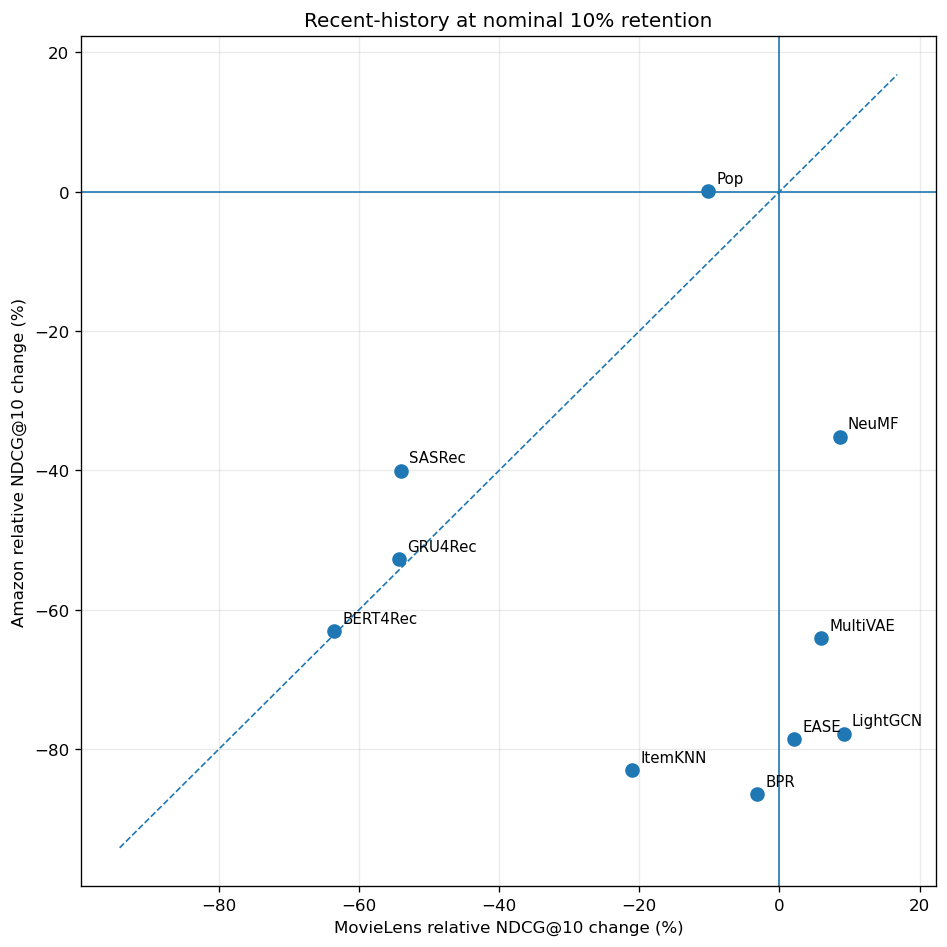

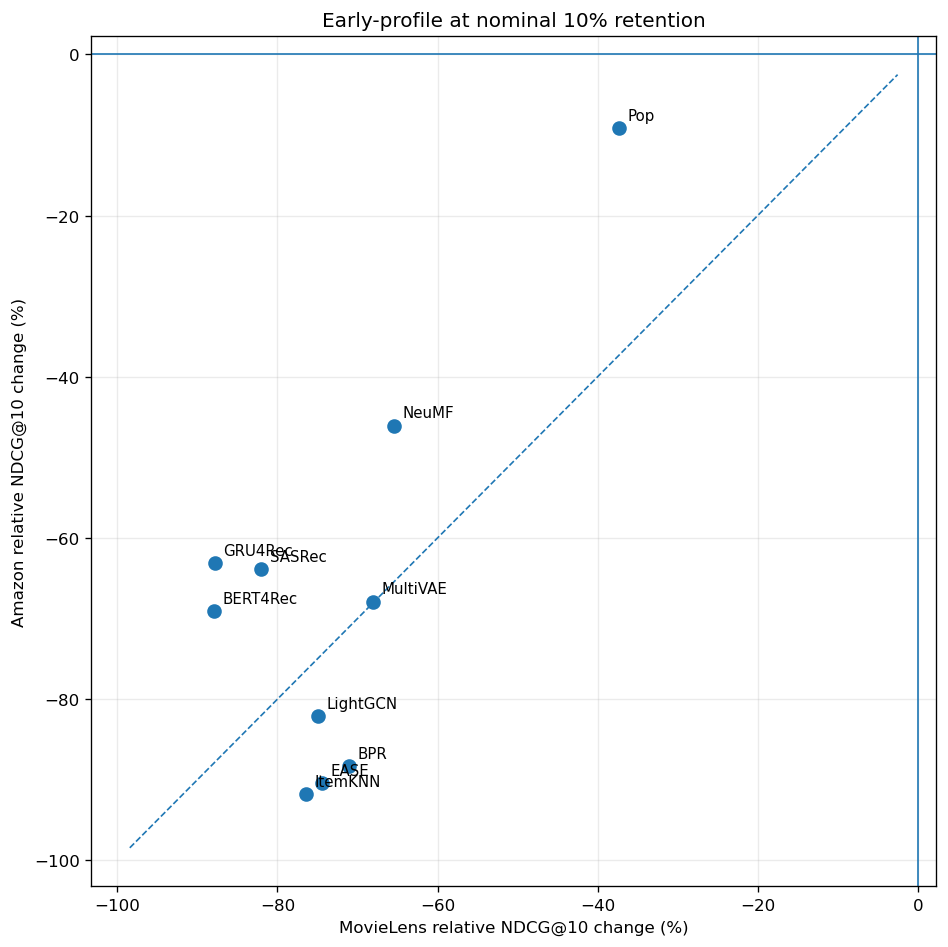

In [13]:
def plot_severe_scatter(
    table,
    scenario,
    filename,
):

    x_col = (
        "relative_change_ndcg10_pct_mean_movielens"
    )

    y_col = (
        "relative_change_ndcg10_pct_mean_amazon"
    )

    fig, ax = plt.subplots(
        figsize=(8, 8)
    )

    ax.scatter(
        table[x_col],
        table[y_col],
        s=60,
    )

    for _, row in table.iterrows():
        ax.annotate(
            row["model"],
            (
                row[x_col],
                row[y_col],
            ),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=9,
        )

    lower = min(
        table[x_col].min(),
        table[y_col].min(),
    )

    upper = max(
        table[x_col].max(),
        table[y_col].max(),
    )

    padding = (
        upper - lower
    ) * 0.08

    ax.plot(
        [
            lower - padding,
            upper + padding,
        ],
        [
            lower - padding,
            upper + padding,
        ],
        linestyle="--",
        linewidth=1,
    )

    ax.axhline(
        0,
        linewidth=1,
    )

    ax.axvline(
        0,
        linewidth=1,
    )

    ax.set_xlabel(
        "MovieLens relative NDCG@10 change (%)"
    )

    ax.set_ylabel(
        "Amazon relative NDCG@10 change (%)"
    )

    ax.set_title(
        f"{SCENARIO_LABELS[scenario]} "
        "at nominal 10% retention"
    )

    fig.tight_layout()

    save_figure(
        fig,
        filename,
    )

    plt.show()


for scenario in SPARSE_SCENARIOS:

    plot_severe_scatter(
        severe_tables[scenario],
        scenario,
        (
            f"{scenario}_10pct_"
            "cross_dataset_robustness"
        ),
    )

## 6.3 Robustness agreement

Calculate whether models that are relatively robust on one dataset also tend to be relatively robust on the other.

Spearman correlations are descriptive because only ten models are compared.

In [14]:
robustness_agreement_rows = []

for scenario in SPARSE_SCENARIOS:

    table = severe_tables[
        scenario
    ]

    correlation = table[
        "relative_change_ndcg10_pct_mean_movielens"
    ].corr(
        table[
            "relative_change_ndcg10_pct_mean_amazon"
        ],
        method="spearman",
    )

    robustness_agreement_rows.append({
        "Scenario": (
            SCENARIO_LABELS[
                scenario
            ]
        ),
        "MovieLens vs Amazon Robustness Spearman": (
            correlation
        ),
    })


robustness_agreement = pd.DataFrame(
    robustness_agreement_rows
)

display(
    robustness_agreement
    .style.format({
        "MovieLens vs Amazon Robustness Spearman":
            "{:.3f}",
    })
)

,Scenario,MovieLens vs Amazon Robustness Spearman
0,Random per-user,0.467
1,Recent-history,-0.152
2,Early-profile,0.309


# 7. Cross-Dataset Ranking Stability

## 7.1 NDCG@10 ranking agreement

Calculate the Spearman correlation between MovieLens and Amazon model rankings for every matching experimental condition.

This indicates whether sparsity causes the two datasets to favour increasingly different models.

In [15]:
rank_agreement_rows = []


conditions = [
    ("baseline", 100),
    ("global", 50),
    ("global", 25),
    ("global", 10),
    ("recent", 50),
    ("recent", 25),
    ("recent", 10),
    ("early", 50),
    ("early", 25),
    ("early", 10),
]


for scenario, retention in conditions:

    subset = sparsity_summary[
        (
            sparsity_summary[
                "scenario"
            ] == scenario
        )
        & (
            sparsity_summary[
                "retention_level"
            ] == retention
        )
    ][
        [
            "dataset",
            "model",
            "test_ndcg@10_rank",
        ]
    ]

    pivot = subset.pivot(
        index="model",
        columns="dataset",
        values="test_ndcg@10_rank",
    )

    correlation = (
        pivot["movielens"]
        .corr(
            pivot["amazon"],
            method="spearman",
        )
    )

    rank_agreement_rows.append({
        "Condition": (
            condition_label(
                scenario,
                retention,
            )
        ),
        "Scenario": scenario,
        "Retention": retention,
        "Rank Spearman": correlation,
    })


rank_agreement = pd.DataFrame(
    rank_agreement_rows
)


display(
    rank_agreement.style.format({
        "Rank Spearman": "{:.3f}",
    })
)

,Condition,Scenario,Retention,Rank Spearman
0,Baseline,baseline,100,0.939
1,Random per-user 50%,global,50,0.491
2,Random per-user 25%,global,25,0.552
3,Random per-user 10%,global,10,0.915
4,Recent-history 50%,recent,50,0.515
5,Recent-history 25%,recent,25,0.382
6,Recent-history 10%,recent,10,0.370
7,Early-profile 50%,early,50,0.648
8,Early-profile 25%,early,25,-0.018
9,Early-profile 10%,early,10,0.794


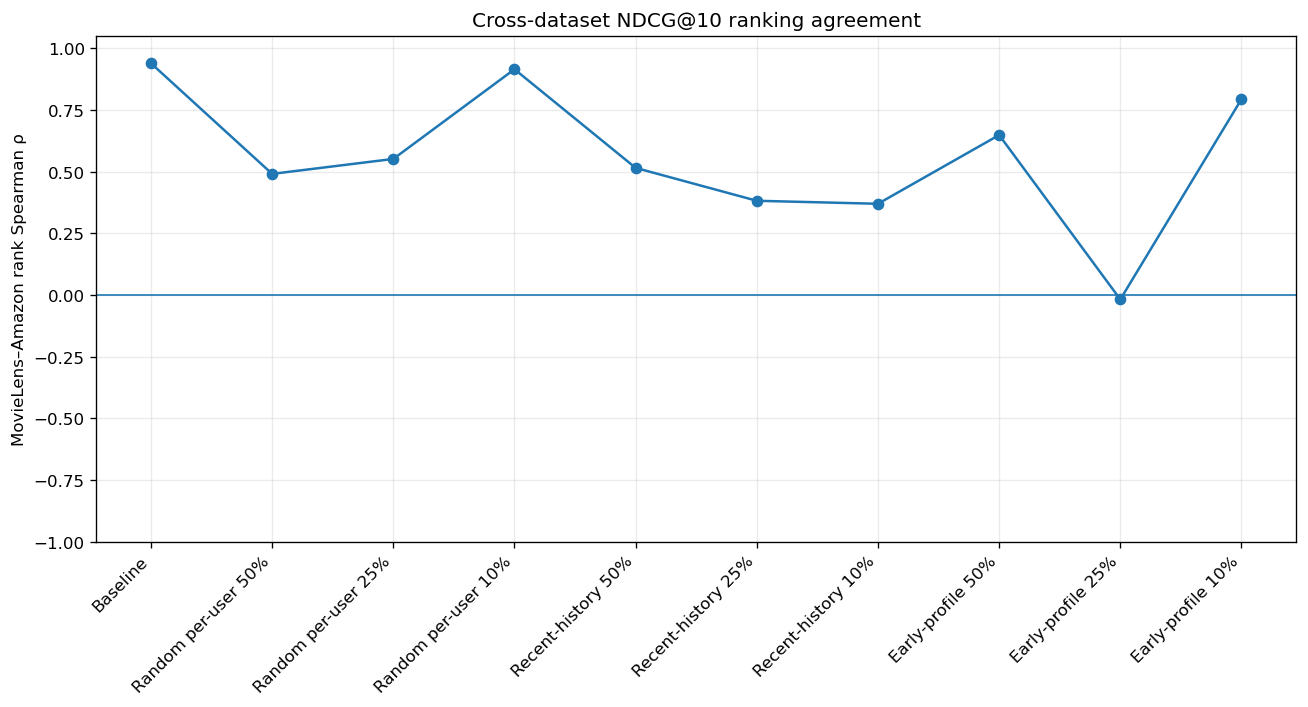

In [16]:
fig, ax = plt.subplots(
    figsize=(11, 6)
)

x = np.arange(
    len(rank_agreement)
)

ax.plot(
    x,
    rank_agreement[
        "Rank Spearman"
    ],
    marker="o",
)

ax.set_xticks(
    x,
    rank_agreement[
        "Condition"
    ],
    rotation=45,
    ha="right",
)

ax.set_ylim(
    -1,
    1.05,
)

ax.set_ylabel(
    "MovieLens–Amazon rank Spearman ρ"
)

ax.set_title(
    "Cross-dataset NDCG@10 ranking agreement"
)

ax.axhline(
    0,
    linewidth=1,
)

fig.tight_layout()

save_figure(
    fig,
    "rank_agreement_by_condition",
)

plt.show()

# 8. Unseen-Target Comparison

## 8.1 Evaluation-target exposure

Compare how frequently held-out test items become completely unseen in training on MovieLens and Amazon.

This provides one explanation for why reduced interaction data may affect the datasets differently.

In [17]:
unseen_comparison = (
    condition_stats[
        [
            "dataset",
            "scenario",
            "retention_level",
            "actual_retention_percent",
            "training_unique_items",
            "test_unseen_percent",
        ]
    ]
    .copy()
)


unseen_comparison[
    "Dataset"
] = unseen_comparison[
    "dataset"
].map(DATASET_LABELS)

unseen_comparison[
    "Scenario"
] = unseen_comparison[
    "scenario"
].map(SCENARIO_LABELS)


display(
    unseen_comparison[
        [
            "Dataset",
            "Scenario",
            "retention_level",
            "actual_retention_percent",
            "training_unique_items",
            "test_unseen_percent",
        ]
    ]
    .rename(columns={
        "retention_level":
            "Nominal Retention (%)",
        "actual_retention_percent":
            "Actual Retention (%)",
        "training_unique_items":
            "Training Items",
        "test_unseen_percent":
            "Test Targets Unseen (%)",
    })
    .style.format({
        "Actual Retention (%)": "{:.3f}%",
        "Test Targets Unseen (%)": "{:.3f}%",
    })
)

,Dataset,Scenario,Nominal Retention (%),Actual Retention (%),Training Items,Test Targets Unseen (%)
0,Amazon Video Games,Baseline,100,100.000%,18966,0.358%
1,Amazon Video Games,Early-profile,10,18.380%,14478,13.177%
2,Amazon Video Games,Early-profile,25,29.767%,16375,8.621%
3,Amazon Video Games,Early-profile,50,54.712%,18184,3.331%
4,Amazon Video Games,Random per-user,10,18.380%,15029,9.071%
5,Amazon Video Games,Random per-user,25,29.767%,17109,4.889%
6,Amazon Video Games,Random per-user,50,54.712%,18565,1.667%
7,Amazon Video Games,Recent-history,10,18.380%,14919,6.894%
8,Amazon Video Games,Recent-history,25,29.767%,17075,3.301%
9,Amazon Video Games,Recent-history,50,54.712%,18604,1.116%


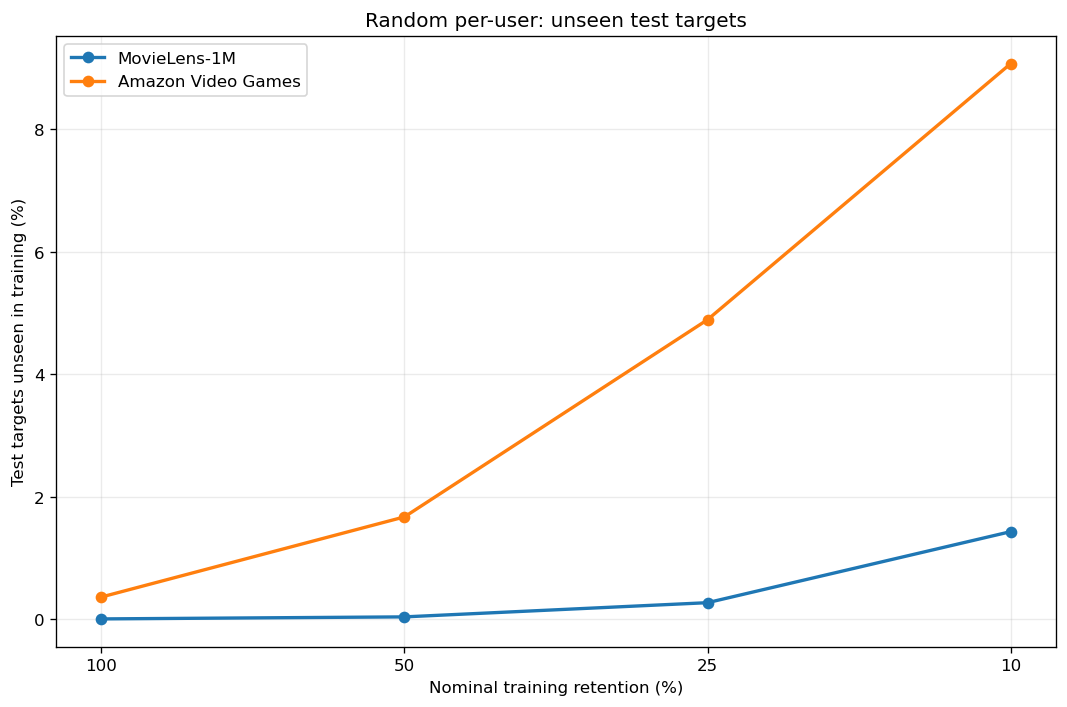

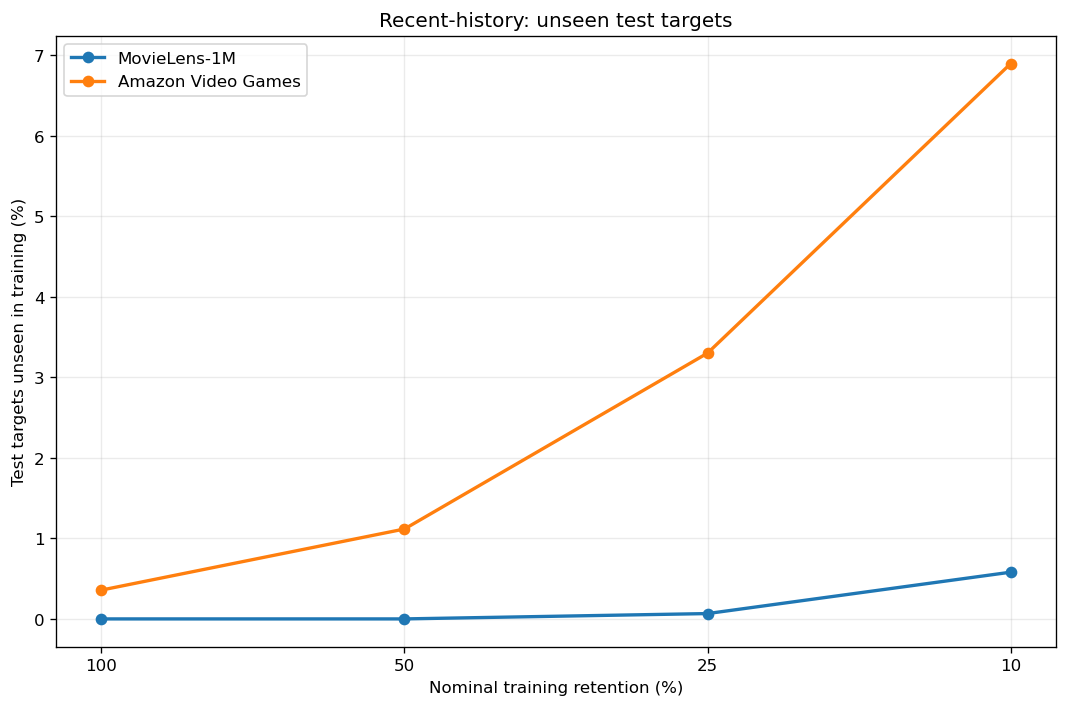

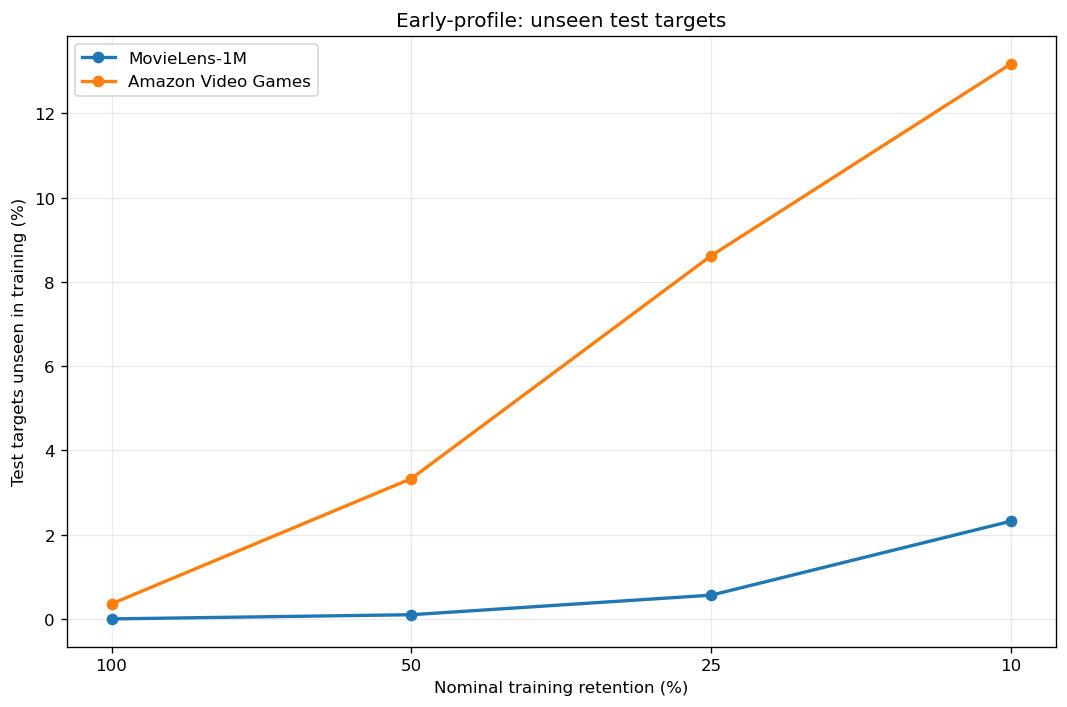

In [18]:
def plot_cross_dataset_unseen(
    condition_stats,
    scenario,
    filename,
):

    fig, ax = plt.subplots(
        figsize=(9, 6)
    )

    x_labels = [
        "100",
        "50",
        "25",
        "10",
    ]

    x = np.arange(
        len(x_labels)
    )

    for dataset in [
        "movielens",
        "amazon",
    ]:

        dataset_subset = (
            condition_stats[
                condition_stats[
                    "dataset"
                ] == dataset
            ]
        )

        baseline_value = (
            dataset_subset[
                dataset_subset[
                    "scenario"
                ] == "baseline"
            ][
                "test_unseen_percent"
            ].iloc[0]
        )

        values = [
            baseline_value
        ]

        for retention in [
            50,
            25,
            10,
        ]:

            value = dataset_subset[
                (
                    dataset_subset[
                        "scenario"
                    ] == scenario
                )
                & (
                    dataset_subset[
                        "retention_level"
                    ] == retention
                )
            ][
                "test_unseen_percent"
            ].iloc[0]

            values.append(value)

        ax.plot(
            x,
            values,
            marker="o",
            linewidth=2,
            label=DATASET_LABELS[
                dataset
            ],
        )

    ax.set_xticks(
        x,
        x_labels,
    )

    ax.set_xlabel(
        "Nominal training retention (%)"
    )

    ax.set_ylabel(
        "Test targets unseen in training (%)"
    )

    ax.set_title(
        f"{SCENARIO_LABELS[scenario]}: "
        "unseen test targets"
    )

    ax.legend()

    fig.tight_layout()

    save_figure(
        fig,
        filename,
    )

    plt.show()


for scenario in SPARSE_SCENARIOS:

    plot_cross_dataset_unseen(
        condition_stats,
        scenario,
        f"{scenario}_unseen_targets_cross_dataset",
    )

# 9. Model-Family Patterns

## 9.1 Family-level observations

Summarise individual model rankings by recommendation family without averaging model performance within families.

This avoids giving unequal-size families artificial statistical weight.

In [19]:
family_rank_summary = (
    sparsity_summary[
        [
            "dataset",
            "scenario",
            "retention_level",
            "model",
            "model_family",
            "test_ndcg@10_rank",
        ]
    ]
    .copy()
)


family_rank_summary[
    "Condition"
] = [
    condition_label(
        scenario,
        retention,
    )
    for scenario, retention in zip(
        family_rank_summary["scenario"],
        family_rank_summary[
            "retention_level"
        ],
    )
]


family_rank_summary = (
    family_rank_summary
    .sort_values(
        [
            "dataset",
            "model_family",
            "model",
            "scenario",
            "retention_level",
        ]
    )
)


display(
    family_rank_summary.head(30)
)

,dataset,scenario,retention_level,model,model_family,test_ndcg@10_rank,Condition
1,amazon,baseline,100,BPR,Classical,6,Baseline
11,amazon,early,10,BPR,Classical,8,Early-profile 10%
21,amazon,early,25,BPR,Classical,9,Early-profile 25%
31,amazon,early,50,BPR,Classical,4,Early-profile 50%
41,amazon,global,10,BPR,Classical,8,Random per-user 10%
51,amazon,global,25,BPR,Classical,9,Random per-user 25%
61,amazon,global,50,BPR,Classical,5,Random per-user 50%
71,amazon,recent,10,BPR,Classical,9,Recent-history 10%
81,amazon,recent,25,BPR,Classical,8,Recent-history 25%
91,amazon,recent,50,BPR,Classical,5,Recent-history 50%


# 10. Cross-Dataset Condition Winners

## 10.1 Highest-ranked model by condition

Identify the numerically highest mean NDCG@10 model under each condition in both datasets.

In [20]:
winner_rows = []

for (
    dataset,
    scenario,
    retention,
), group in sparsity_summary.groupby(
    [
        "dataset",
        "scenario",
        "retention_level",
    ]
):

    winner = group.sort_values(
        "test_ndcg@10_mean",
        ascending=False,
    ).iloc[0]

    winner_rows.append({
        "Dataset": (
            DATASET_LABELS[
                dataset
            ]
        ),
        "Condition": (
            condition_label(
                scenario,
                retention,
            )
        ),
        "Scenario": (
            SCENARIO_LABELS[
                scenario
            ]
        ),
        "Retention": retention,
        "Winner": winner["model"],
        "Mean NDCG@10": (
            winner[
                "test_ndcg@10_mean"
            ]
        ),
    })


condition_winners = (
    pd.DataFrame(
        winner_rows
    )
)


display(
    condition_winners.style.format({
        "Mean NDCG@10": "{:.6f}",
    })
)

,Dataset,Condition,Scenario,Retention,Winner,Mean NDCG@10
0,Amazon Video Games,Baseline,Baseline,100,SASRec,0.046315
1,Amazon Video Games,Early-profile 10%,Early-profile,10,SASRec,0.016713
2,Amazon Video Games,Early-profile 25%,Early-profile,25,SASRec,0.019885
3,Amazon Video Games,Early-profile 50%,Early-profile,50,SASRec,0.033990
4,Amazon Video Games,Random per-user 10%,Random per-user,10,GRU4Rec,0.020602
5,Amazon Video Games,Random per-user 25%,Random per-user,25,SASRec,0.024978
6,Amazon Video Games,Random per-user 50%,Random per-user,50,SASRec,0.033523
7,Amazon Video Games,Recent-history 10%,Recent-history,10,SASRec,0.027772
8,Amazon Video Games,Recent-history 25%,Recent-history,25,SASRec,0.031443
9,Amazon Video Games,Recent-history 50%,Recent-history,50,SASRec,0.036706


In [21]:
winner_comparison = (
    condition_winners
    .pivot(
        index=[
            "Condition",
            "Scenario",
            "Retention",
        ],
        columns="Dataset",
        values="Winner",
    )
    .reset_index()
)


display(
    winner_comparison
)

Dataset,Condition,Scenario,Retention,Amazon Video Games,MovieLens-1M
0,Baseline,Baseline,100,SASRec,SASRec
1,Early-profile 10%,Early-profile,10,SASRec,SASRec
2,Early-profile 25%,Early-profile,25,SASRec,SASRec
3,Early-profile 50%,Early-profile,50,SASRec,SASRec
4,Random per-user 10%,Random per-user,10,GRU4Rec,SASRec
5,Random per-user 25%,Random per-user,25,SASRec,GRU4Rec
6,Random per-user 50%,Random per-user,50,SASRec,SASRec
7,Recent-history 10%,Recent-history,10,SASRec,SASRec
8,Recent-history 25%,Recent-history,25,SASRec,GRU4Rec
9,Recent-history 50%,Recent-history,50,SASRec,SASRec


# 11. Key Cross-Dataset Summary Tables

## 11.1 Severe-sparsity model summary

Create one compact table comparing each model under the nominal 10% conditions across both datasets.

In [22]:
severe_summary_rows = []

for model in MODEL_ORDER:

    row = {
        "Model": model,
        "Family": MODEL_FAMILY[
            model
        ],
    }

    for dataset in [
        "movielens",
        "amazon",
    ]:

        for scenario in SPARSE_SCENARIOS:

            match = sparsity_summary[
                (
                    sparsity_summary[
                        "dataset"
                    ] == dataset
                )
                & (
                    sparsity_summary[
                        "scenario"
                    ] == scenario
                )
                & (
                    sparsity_summary[
                        "retention_level"
                    ] == 10
                )
                & (
                    sparsity_summary[
                        "model"
                    ] == model
                )
            ].iloc[0]

            prefix = (
                f"{dataset}_"
                f"{scenario}"
            )

            row[
                f"{prefix}_ndcg"
            ] = match[
                "test_ndcg@10_mean"
            ]

            row[
                f"{prefix}_change"
            ] = match[
                "relative_change_ndcg10_pct_mean"
            ]

            row[
                f"{prefix}_rank"
            ] = match[
                "test_ndcg@10_rank"
            ]

    severe_summary_rows.append(row)


severe_cross_dataset_summary = (
    pd.DataFrame(
        severe_summary_rows
    )
)


display(
    severe_cross_dataset_summary
)

,Model,Family,movielens_global_ndcg,movielens_global_change,movielens_global_rank,movielens_recent_ndcg,movielens_recent_change,movielens_recent_rank,movielens_early_ndcg,movielens_early_change,movielens_early_rank,amazon_global_ndcg,amazon_global_change,amazon_global_rank,amazon_recent_ndcg,amazon_recent_change,amazon_recent_rank,amazon_early_ndcg,amazon_early_change,amazon_early_rank
0,Pop,Non-personalized,0.013303,-30.561645,4,0.017196,-10.241153,10,0.012014,-37.289905,5,0.015739,-3.174408,3,0.016263,0.049216,3,0.014770,-9.135651,3
1,ItemKNN,Classical,0.000957,-97.433353,10,0.029457,-20.997157,9,0.008786,-76.436196,10,0.002242,-90.678142,10,0.004084,-83.019417,10,0.001965,-91.829862,10
2,BPR,Classical,0.009634,-74.644296,9,0.036775,-3.213357,7,0.011007,-71.023230,8,0.004441,-87.464801,8,0.004792,-86.480335,9,0.004154,-88.280582,8
3,EASE,Linear,0.011213,-75.168305,7,0.046078,2.041811,3,0.011551,-74.419789,6,0.004134,-89.806436,9,0.008705,-78.535322,7,0.003878,-90.437677,9
4,NeuMF,Neural,0.012062,-62.305054,5,0.034686,8.562251,8,0.011035,-65.392690,7,0.015325,-36.993445,4,0.015770,-35.168911,4,0.013123,-46.084203,4
5,MultiVAE,Neural,0.011223,-71.342997,6,0.041512,5.943946,5,0.012501,-68.094661,4,0.012034,-65.267716,6,0.012462,-64.034216,6,0.011106,-67.911812,6
6,GRU4Rec,Sequential,0.022897,-79.656522,2,0.051480,-54.240765,2,0.013747,-87.784573,2,0.020602,-54.126571,1,0.021246,-52.707021,2,0.016547,-63.160541,2
7,SASRec,Sequential,0.026539,-77.706536,1,0.054733,-54.027775,1,0.021299,-82.010956,1,0.020016,-56.786029,2,0.027772,-40.027483,1,0.016713,-63.910864,1
8,BERT4Rec,Sequential,0.017363,-83.731154,3,0.038849,-63.558988,6,0.012949,-87.883619,3,0.014880,-61.961878,5,0.014456,-63.048382,5,0.012086,-69.119437,5
9,LightGCN,Graph,0.011183,-70.599034,8,0.041545,9.133216,4,0.009538,-74.938489,9,0.006863,-80.855788,7,0.007964,-77.779484,8,0.006417,-82.104133,7


# 12. Cross-Dataset Findings

## 12.1 Findings to record

After reviewing the tables and figures, record the main cross-dataset conclusions.

Consider:

- Are baseline model rankings similar across MovieLens and Amazon?
- Do sequential models remain strongest across both datasets?
- Does SASRec remain the most consistently high-performing model?
- Under which conditions does GRU4Rec overtake SASRec?
- Does EASE behave differently across the two datasets?
- Which models show the largest dataset-dependent changes in robustness?
- Is recent-history retention consistently less damaging than random or early-profile retention?
- Does early-profile retention have a stronger effect on sequential models?
- Does popularity become more competitive under severe sparsity?
- Does ItemKNN deteriorate strongly under sparse interaction structure?
- Does Amazon exhibit more unseen evaluation targets than MovieLens?
- How does Amazon's short training history affect interpretation of nominal retention levels?
- Are cross-dataset model rankings less consistent as sparsity becomes more severe?
- Which findings appear general across datasets, and which appear dataset-specific?

These observations will later form the basis of the cross-dataset Results subsection and the main Discussion chapter.

# 13. Export Results

## 13.1 Export cross-dataset tables

Save the major cross-dataset analysis tables for later dissertation use.

In [23]:
dataset_context.to_csv(
    TABLE_DIR
    / "dataset_context.csv",
    index=False,
)

retention_comparison.to_csv(
    TABLE_DIR
    / "nominal_actual_retention_comparison.csv",
    index=False,
)

baseline_rank_table.to_csv(
    TABLE_DIR
    / "baseline_rank_comparison.csv",
    index=False,
)

dataset_robustness.to_csv(
    TABLE_DIR
    / "dataset_robustness_summary.csv",
    index=False,
)

robustness_agreement.to_csv(
    TABLE_DIR
    / "severe_robustness_agreement.csv",
    index=False,
)

rank_agreement.to_csv(
    TABLE_DIR
    / "rank_agreement_by_condition.csv",
    index=False,
)

unseen_comparison.to_csv(
    TABLE_DIR
    / "unseen_target_comparison.csv",
    index=False,
)

family_rank_summary.to_csv(
    TABLE_DIR
    / "family_rank_summary.csv",
    index=False,
)

condition_winners.to_csv(
    TABLE_DIR
    / "condition_winners.csv",
    index=False,
)

winner_comparison.to_csv(
    TABLE_DIR
    / "condition_winner_comparison.csv",
    index=False,
)

severe_cross_dataset_summary.to_csv(
    TABLE_DIR
    / "severe_cross_dataset_summary.csv",
    index=False,
)


for scenario, table in severe_tables.items():

    table.to_csv(
        TABLE_DIR
        / (
            f"{scenario}_10pct_"
            "cross_dataset_model_comparison.csv"
        ),
        index=False,
    )


print("Cross-dataset tables saved:")

for path in sorted(
    TABLE_DIR.glob("*.csv")
):
    print(
        f"  {path.relative_to(ROOT)}"
    )


print("\nCross-dataset figures saved:")

for path in sorted(
    FIGURE_DIR.glob("*")
):
    print(
        f"  {path.relative_to(ROOT)}"
    )

Cross-dataset tables saved:
  results\tables\cross_dataset\baseline_rank_comparison.csv
  results\tables\cross_dataset\condition_winner_comparison.csv
  results\tables\cross_dataset\condition_winners.csv
  results\tables\cross_dataset\dataset_context.csv
  results\tables\cross_dataset\dataset_robustness_summary.csv
  results\tables\cross_dataset\early_10pct_cross_dataset_model_comparison.csv
  results\tables\cross_dataset\family_rank_summary.csv
  results\tables\cross_dataset\global_10pct_cross_dataset_model_comparison.csv
  results\tables\cross_dataset\nominal_actual_retention_comparison.csv
  results\tables\cross_dataset\rank_agreement_by_condition.csv
  results\tables\cross_dataset\recent_10pct_cross_dataset_model_comparison.csv
  results\tables\cross_dataset\severe_cross_dataset_summary.csv
  results\tables\cross_dataset\severe_robustness_agreement.csv
  results\tables\cross_dataset\unseen_target_comparison.csv

Cross-dataset figures saved:
  results\figures\cross_dataset\baseline_

# 14. Cross-Dataset Analysis Summary

## 14.1 Final status

Confirm that the cross-dataset analysis has been completed and report the broad baseline and sparse-condition winners.

In [24]:
print("=" * 78)
print("CROSS-DATASET ANALYSIS COMPLETE")
print("=" * 78)


for dataset in [
    "movielens",
    "amazon",
]:

    dataset_label = (
        DATASET_LABELS[
            dataset
        ]
    )

    baseline = sparsity_summary[
        (
            sparsity_summary[
                "dataset"
            ] == dataset
        )
        & (
            sparsity_summary[
                "scenario"
            ] == "baseline"
        )
    ].sort_values(
        "test_ndcg@10_mean",
        ascending=False,
    )

    baseline_winner = (
        baseline.iloc[0]
    )

    print(
        f"\n{dataset_label}"
    )

    print(
        f"Baseline winner: "
        f"{baseline_winner['model']} "
        f"({baseline_winner['test_ndcg@10_mean']:.6f})"
    )

    sparse = sparsity_summary[
        (
            sparsity_summary[
                "dataset"
            ] == dataset
        )
        & (
            sparsity_summary[
                "scenario"
            ] != "baseline"
        )
    ]

    win_counts = (
        sparse[
            sparse[
                "test_ndcg@10_rank"
            ] == 1
        ]["model"]
        .value_counts()
    )

    print(
        "Sparse-condition wins:"
    )

    for model, count in (
        win_counts.items()
    ):
        print(
            f"  {model:<9}: "
            f"{count} / 9"
        )


print()
print(
    "Cross-dataset tables and figures are ready "
    "for interpretation and dissertation planning."
)

CROSS-DATASET ANALYSIS COMPLETE

MovieLens-1M
Baseline winner: SASRec (0.119079)
Sparse-condition wins:
  SASRec   : 7 / 9
  GRU4Rec  : 2 / 9

Amazon Video Games
Baseline winner: SASRec (0.046315)
Sparse-condition wins:
  SASRec   : 8 / 9
  GRU4Rec  : 1 / 9

Cross-dataset tables and figures are ready for interpretation and dissertation planning.
